# Credit Risk Model
Enhance the credit risk model for interpretability of tree-based models (Random Forest, LightGBM, XGBoost) and summarize the findings, highlighting the best-performing model and key insights for credit risk management.

## Data Generation - Data Simulation



Generating 50000 customer records...
Training Logit...
Finished Logistic Regression
Training Random Forest...
Finished Random Forest
Training LightGBM...
Finished LightGBM

--- MODEL TOURNAMENT RESULTS ---
                       Gini     AUC  PR_AUC      F1      KS
Logistic Regression  0.9475  0.9737  0.3802  0.1860  0.8439
Random Forest        0.9191  0.9596  0.2700  0.0187  0.8137
LightGBM             0.9216  0.9608  0.2599  0.3206  0.8234


<Figure size 1000x600 with 0 Axes>

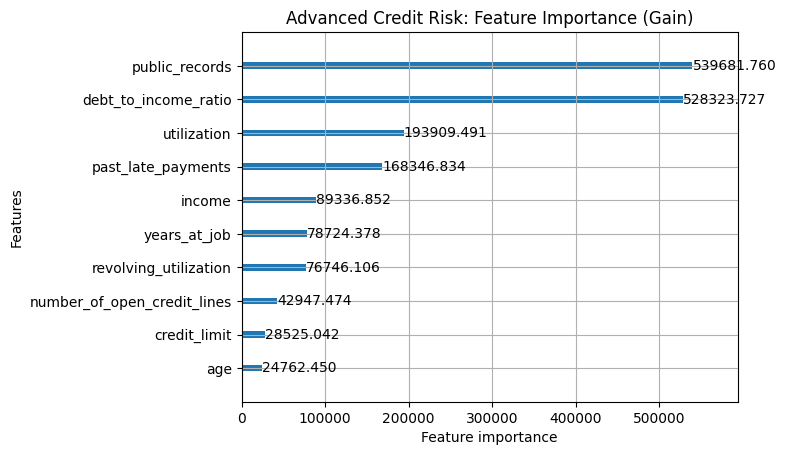

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score, f1_score
from scipy.stats import ks_2samp
import lightgbm as lgb

# ==========================================
# 1. SIMULATION (500K Rows)
# ==========================================
def generate_advanced_data(n=500000):
    np.random.seed(42)
    print(f"Generating {n} customer records...")

    data = pd.DataFrame({
        'age': np.random.randint(18, 75, n),
        'income': np.random.lognormal(10.5, 0.6, n),
        'edu_level': np.random.choice([1, 2, 3, 4], n, p=[0.1, 0.4, 0.3, 0.2]), # 1:High School, 4:PhD
        'years_at_job': np.random.exponential(5, n),
    })

    # Feature Correlation Logic
    data['credit_limit'] = data['income'] * np.random.uniform(0.1, 0.4, n)
    data['utilization'] = np.random.beta(2, 5, n)
    data['past_late_payments'] = np.random.poisson(0.2, n)
    data['revolving_utilization'] = np.random.beta(2, 8, n) # Skewed towards lower utilization
    data['debt_to_income_ratio'] = np.random.lognormal(0.6, 0.4, n) * 100 # Scale to percentage
    data['number_of_open_credit_lines'] = np.random.randint(1, 20, n)
    data['public_records'] = np.random.poisson(0.1, n) # Most values 0 or 1
    data['home_ownership'] = np.random.choice([0, 1, 2], n, p=[0.3, 0.4, 0.3]) # 0:OWN, 1:MORTGAGE, 2:RENT


    risk_score = (
        (data['utilization'] * 4.5) +
        (data['past_late_payments'] * 1.2) -
        (np.log(data['income']) * 0.8) -
        (data['years_at_job'] * 0.1) +
        (data['revolving_utilization'] * 3.0) +
        (data['debt_to_income_ratio'] * 0.01) + # DTI is percentage, so smaller coefficient
        (data['public_records'] * 2.0) +
        (data['home_ownership'] * 0.5) - # 0:OWN (lower risk), 1:MORTGAGE, 2:RENT (higher risk)
        (data['number_of_open_credit_lines'] * 0.05) + # More lines (within reason) slightly lower risk

        np.random.normal(0, 1.5, n)
    )

    data['prob_default'] = 1 / (1 + np.exp(-risk_score))
    data['default'] = (data['prob_default'] > 0.7).astype(int) # Imbalanced Target (~7-9%) - Ensure at least one class, reduced threshold

    return data.drop(columns=['prob_default'])

# ==========================================
# 2. ENGINEERING & PREPROCESSING
# ==========================================
df = generate_advanced_data(n=500000)
X = df.drop('default', axis=1)
y = df['default']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. THE MODEL TOURNAMENT
# ==========================================
results = {}

def evaluate_model(y_true, y_prob, name):
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    pr_auc = average_precision_score(y_true, y_prob)

    # For F1-score, we need a predicted class, not just probabilities.
    y_pred_class = (y_prob > 0.5).astype(int)
    f1 = f1_score(y_true, y_pred_class)

    # Kolmogorov-Smirnov (KS) Statistic
    data = pd.DataFrame({'target': y_true, 'prob': y_prob})

    if len(data[data['target'] == 0]) > 0 and len(data[data['target'] == 1]) > 0:
        ks = ks_2samp(data[data['target'] == 0]['prob'], data[data['target'] == 1]['prob']).statistic
    else:
        ks = np.nan

    results[name] = {'Gini': round(gini, 4), 'AUC': round(auc, 4), 'PR_AUC': round(pr_auc, 4), 'F1': round(f1, 4), 'KS': round(ks, 4)}
    print(f"Finished {name}")

# --- Model 1: Logistic Regression ---
print("Training Logit...")
logit = LogisticRegression(penalty='l2', C=0.1, class_weight='balanced', max_iter=1000)
logit.fit(X_train_scaled, y_train)
evaluate_model(y_test, logit.predict_proba(X_test_scaled)[:, 1], 'Logistic Regression')

# --- Model 2: Random Forest ---
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
evaluate_model(y_test, rf.predict_proba(X_test)[:, 1], 'Random Forest')

# --- Model 3: LightGBM ---
print("Training LightGBM...")
lgb_train = lgb.Dataset(X_train, label=y_train)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'is_unbalance': True,
    'verbosity': -1
}
lgb_model = lgb.train(params, lgb_train, num_boost_round=200)
evaluate_model(y_test, lgb_model.predict(X_test), 'LightGBM')

# ==========================================
# 4. COMPARISON & REPORT
# ==========================================
report = pd.DataFrame(results).T
print("\n--- MODEL RESULTS ---")
print(report)

# Quick Visualization of Feature Importance (from LightGBM)
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='gain')
plt.title("Advanced Credit Risk: Feature Importance (Gain)")
plt.show()

## Advanced Feature
 This will involve handling new categorical variables (e.g., one-hot encoding `edu_level` and `home_ownership`) and potentially generating interaction terms or polynomial features for numerical variables.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify categorical features
categorical_features = ['edu_level', 'home_ownership']


X_train = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# Align columns -
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Shape of X_train after one-hot encoding:", X_train.shape)
print("Shape of X_test after one-hot encoding:", X_test.shape)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dataframes X_train, X_test, X_train_scaled, and X_test_scaled have been updated with one-hot encoded features and re-scaled.")

Shape of X_train after one-hot encoding: (400000, 15)
Shape of X_test after one-hot encoding: (100000, 15)
Dataframes X_train, X_test, X_train_scaled, and X_test_scaled have been updated with one-hot encoded features and re-scaled.


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import pandas as pd


original_numerical_features = [
    'age', 'income', 'years_at_job', 'credit_limit', 'utilization',
    'past_late_payments', 'revolving_utilization', 'debt_to_income_ratio',
    'number_of_open_credit_lines', 'public_records'
]

# Select only the numerical features from X_train and X_test for interaction terms
X_train_numerical = X_train[original_numerical_features]
X_test_numerical = X_test[original_numerical_features]

# Initialize PolynomialFeatures for interaction terms only
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

# Fit and transform on training data, transform on test data
X_train_poly_transformed = poly.fit_transform(X_train_numerical)
X_test_poly_transformed = poly.transform(X_test_numerical)

# Get feature names for ALL features generated
poly_feature_names = poly.get_feature_names_out(original_numerical_features)

# Convert polynomial features arrays back to DataFrames
X_train_poly_df = pd.DataFrame(X_train_poly_transformed, columns=poly_feature_names, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly_transformed, columns=poly_feature_names, index=X_test.index)

# Identify actual interaction terms
interaction_only_cols = [col for col in poly_feature_names if ' ' in col]

# Concatenate only the interaction terms to X_train and X_test
X_train = pd.concat([X_train, X_train_poly_df[interaction_only_cols]], axis=1)
X_test = pd.concat([X_test, X_test_poly_df[interaction_only_cols]], axis=1)

print("Shape of X_train after adding interaction terms:", X_train.shape)
print("Shape of X_test after adding interaction terms:", X_test.shape)

# Re-initialize and refit the StandardScaler on the updated X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dataframes X_train, X_test, X_train_scaled, and X_test_scaled have been updated with interaction features and re-scaled.")

Shape of X_train after adding interaction terms: (40000, 57)
Shape of X_test after adding interaction terms: (10000, 57)
Dataframes X_train, X_test, X_train_scaled, and X_test_scaled have been updated with interaction features and re-scaled.


## Implement XGBoost Classifier

Integrate XGBoost, a powerful gradient boosting model commonly used in credit scoring, into the model tournament. This will involve training an XGBoost classifier on the prepared data and evaluating its performance using the defined metrics.


Training Logit...
Finished Logistic Regression
Training Random Forest...
Finished Random Forest
Training LightGBM...
Finished LightGBM
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:44:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Finished XGBoost

--- MODEL TOURNAMENT RESULTS ---
                       Gini     AUC  PR_AUC      F1      KS
Logistic Regression  0.9475  0.9737  0.3802  0.1860  0.8439
Random Forest        0.9191  0.9596  0.2700  0.0187  0.8137
LightGBM             0.9216  0.9608  0.2599  0.3206  0.8234
XGBoost              0.9189  0.9595  0.2646  0.2961  0.8080


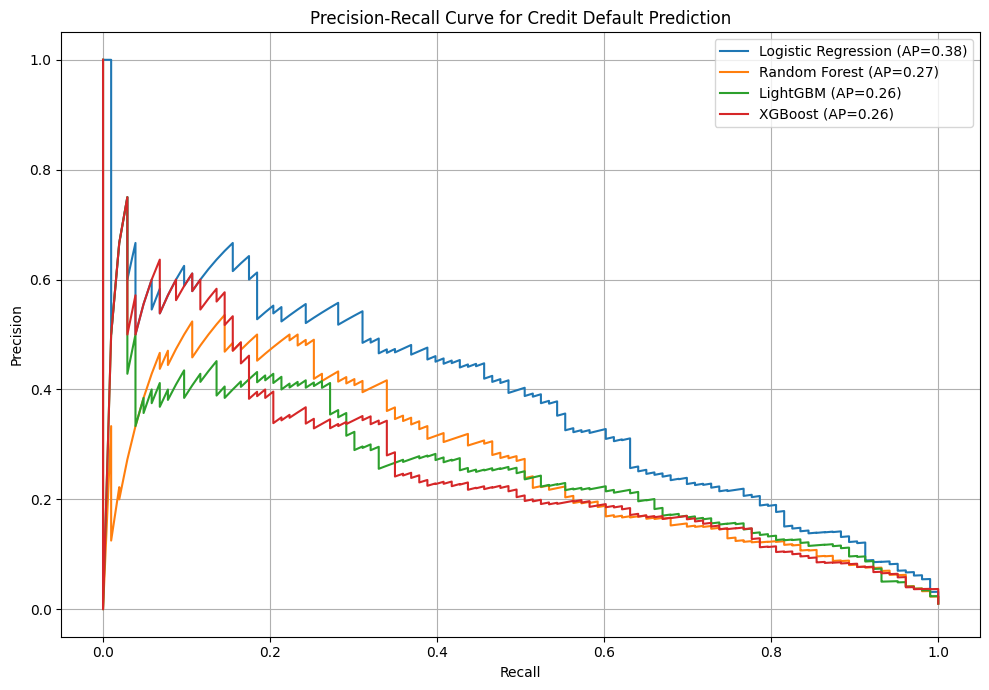


Generating SHAP Summary Plots for Tree Models...


/tmp/ipykernel_206/1702203918.py:109: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rf[1], X_test_xgb, show=False)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1200x800 with 0 Axes>

In [ ]:
import xgboost as xgb
import shap

# Ensure X_train and X_test are numerical for XGBoost
X_train_xgb = X_train.astype(float)
X_test_xgb = X_test.astype(float)

# --- Model 1: Penalized Logistic Regression ---
print("Training Logit...")
logit = LogisticRegression(penalty='l2', C=0.1, class_weight='balanced', max_iter=1000)
logit.fit(X_train_scaled, y_train)
logit_y_prob = logit.predict_proba(X_test_scaled)[:, 1]
evaluate_model(y_test, logit_y_prob, 'Logistic Regression')

# --- Model 2: Random Forest ---
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train_xgb, y_train)
rf_y_prob = rf.predict_proba(X_test_xgb)[:, 1]
evaluate_model(y_test, rf_y_prob, 'Random Forest')

# --- Model 3: LightGBM ---
print("Training LightGBM...")
lgb_train = lgb.Dataset(X_train_xgb, label=y_train, feature_name=list(X_train_xgb.columns))
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'is_unbalance': True,
    'verbosity': -1
}
lgb_model = lgb.train(params, lgb_train, num_boost_round=200)
lgb_y_prob = lgb_model.predict(X_test_xgb)
evaluate_model(y_test, lgb_y_prob, 'LightGBM')

# --- Model 4: XGBoost ---
print("Training XGBoost...")

# Calculate scale_pos_weight for imbalanced dataset
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)
# Train XGBoost on the numerical X_train_xgb and X_test_xgb
xgb_model.fit(X_train_xgb, y_train)
xgb_y_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]
evaluate_model(y_test, xgb_y_prob, 'XGBoost')

# ==========================================
# 4. FINAL COMPARISON & REPORT (Updated to include XGBoost)
# ==========================================
report = pd.DataFrame(results).T
print("\n--- MODEL TOURNAMENT RESULTS ---")
print(report)

# ==========================================
# 5. VISUALIZATIONS
# ==========================================

# 5.1 Precision-Recall Curves
plt.figure(figsize=(10, 7))
models_to_plot = {
    'Logistic Regression': logit_y_prob,
    'Random Forest': rf_y_prob,
    'LightGBM': lgb_y_prob,
    'XGBoost': xgb_y_prob
}

for name, y_prob in models_to_plot.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=f'{name} (AP={average_precision_score(y_test, y_prob):.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Credit Default Prediction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 5.2 SHAP for Tree-based Models
print("\nGenerating SHAP Summary Plots for Tree Models...")

# Random Forest SHAP
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test_xgb)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_rf[1], X_test_xgb, show=False)
plt.title('SHAP Summary Plot - Random Forest (Positive Class)')
plt.tight_layout()
plt.show()

# LightGBM SHAP
explainer_lgbm = shap.TreeExplainer(lgb_model)
shap_values_lgbm = explainer_lgbm.shap_values(X_test_xgb)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_lgbm, X_test_xgb, show=False)
plt.title('SHAP Summary Plot - LightGBM')
plt.tight_layout()
plt.show()

# XGBoost SHAP
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_xgb)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_xgb, X_test_xgb, show=False)
plt.title('SHAP Summary Plot - XGBoost')
plt.tight_layout()
plt.show()

print("\nAdvanced visualizations complete.")

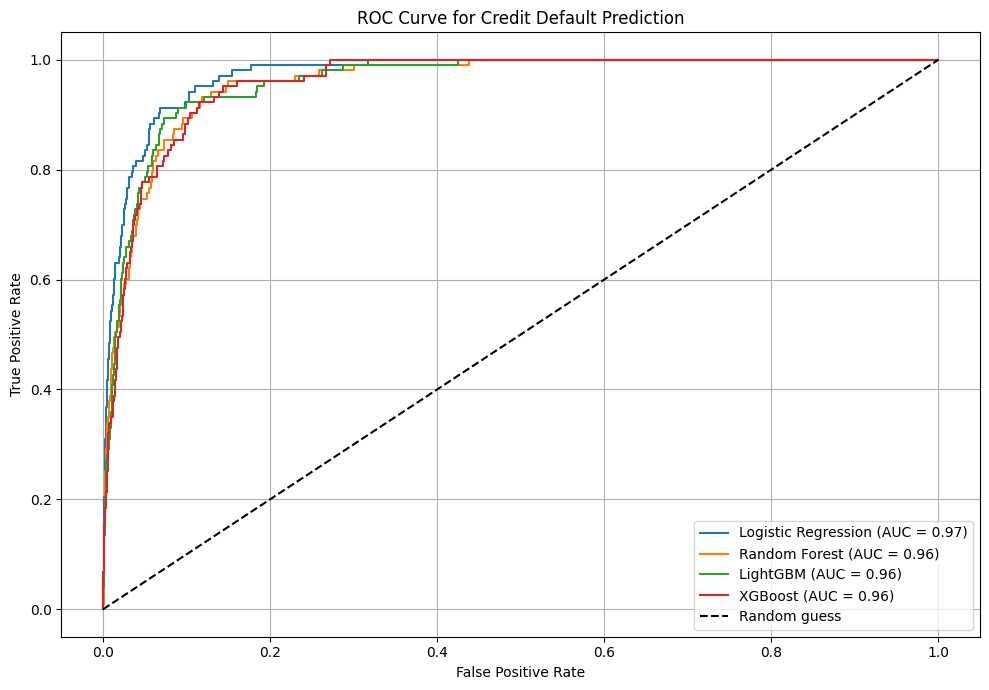


ROC AUC curve comparison generated.


In [ ]:
from sklearn.metrics import roc_curve, auc

# 5.3 ROC AUC Curves
plt.figure(figsize=(10, 7))

models_to_plot = {
    'Logistic Regression': logit_y_prob,
    'Random Forest': rf_y_prob,
    'LightGBM': lgb_y_prob,
    'XGBoost': xgb_y_prob
}

for name, y_prob in models_to_plot.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Credit Default Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nROC AUC curve comparison generated.")


Generating 3D plot for LightGBM predictions...


/tmp/ipykernel_206/2857959580.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  predict_df = pd.concat([predict_df, temp_df], ignore_index=True)


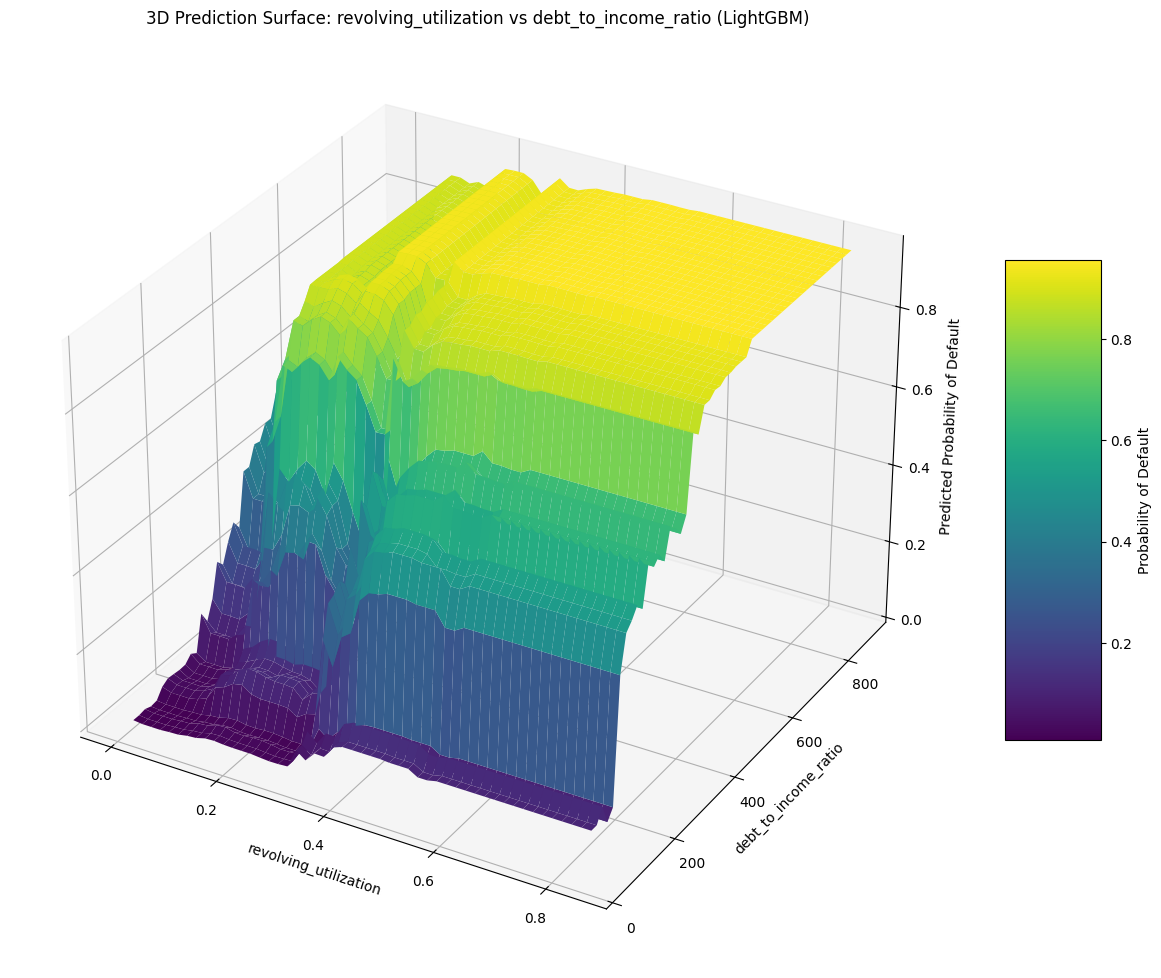


3D prediction surface plot generated.


In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# 3D Visualization of Model Predictions (LightGBM)
print("\nGenerating 3D plot for LightGBM predictions...")

# Choose two important features based on SHAP analysis
feature1 = 'revolving_utilization'
feature2 = 'debt_to_income_ratio'


base_df = X_test_xgb.mean().to_frame().T

# Create a meshgrid for the two chosen features

rev_util_range = np.linspace(X_test_xgb[feature1].min(), X_test_xgb[feature1].max(), 50)
dti_ratio_range = np.linspace(X_test_xgb[feature2].min(), X_test_xgb[feature2].max(), 50)

REV_UTIL, DTI_RATIO = np.meshgrid(rev_util_range, dti_ratio_range)

# Prepare a DataFrame for 3D predictions
predict_df = pd.DataFrame(columns=X_test_xgb.columns)

for i in range(REV_UTIL.shape[0]):
    for j in range(REV_UTIL.shape[1]):
        temp_df = base_df.copy()
        temp_df[feature1] = REV_UTIL[i, j]
        temp_df[feature2] = DTI_RATIO[i, j]
        predict_df = pd.concat([predict_df, temp_df], ignore_index=True)

predict_df = predict_df[X_test_xgb.columns]

# Get predictions from LightGBM model
predictions_3d = lgb_model.predict(predict_df.astype(float)).reshape(REV_UTIL.shape)

# Plotting
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(REV_UTIL, DTI_RATIO, predictions_3d, cmap='viridis')

ax.set_xlabel(feature1)
ax.set_ylabel(feature2)
ax.set_zlabel('Predicted Probability of Default')
ax.set_title(f'3D Prediction Surface: {feature1} vs {feature2} (LightGBM)')

fig.colorbar(surf, shrink=0.5, aspect=5, label='Probability of Default')
plt.tight_layout()
plt.show()

print("\n3D prediction surface plot generated.")


Generating 3D plot for XGBoost predictions...


/tmp/ipykernel_206/2275392772.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  predict_df = pd.concat([predict_df, temp_df], ignore_index=True)


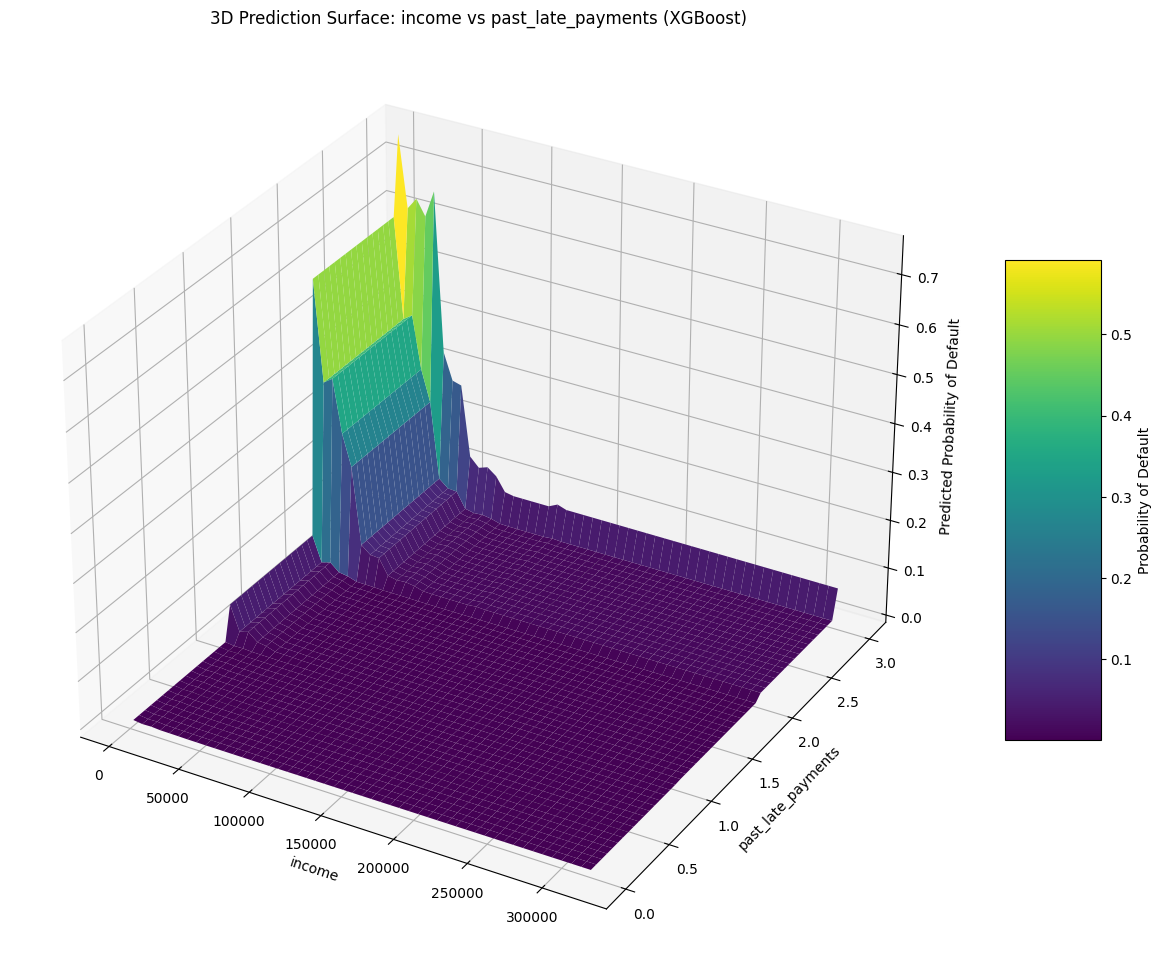


3D prediction surface plot generated for XGBoost.


In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# 5.5 3D Visualization of Model Predictions (XGBoost)
print("\nGenerating 3D plot for XGBoost predictions...")

# Choose the model and features as requested by the user
model_to_plot = xgb_model
model_name = 'XGBoost'
feature1 = 'income' #public_records or age etc
feature2 = 'past_late_payments'

# Create a base DataFrame for prediction, using mean values for all features
base_df = X_test_xgb.mean().to_frame().T


income_range = np.linspace(X_test_xgb[feature1].min(), X_test_xgb[feature1].max(), 50)
past_late_payments_range = np.linspace(X_test_xgb[feature2].min(), X_test_xgb[feature2].max(), 50)

FEATURE1_MESH, FEATURE2_MESH = np.meshgrid(income_range, past_late_payments_range)

# Prepare a DataFrame for 3D predictions
predict_df = pd.DataFrame(columns=X_test_xgb.columns)

for i in range(FEATURE1_MESH.shape[0]):
    for j in range(FEATURE1_MESH.shape[1]):
        temp_df = base_df.copy()
        temp_df[feature1] = FEATURE1_MESH[i, j]
        temp_df[feature2] = FEATURE2_MESH[i, j]
        predict_df = pd.concat([predict_df, temp_df], ignore_index=True)

# Ensure column order is correct for prediction
predict_df = predict_df[X_test_xgb.columns]

# Get predictions from the chosen model
predictions_3d = model_to_plot.predict_proba(predict_df.astype(float))[:, 1].reshape(FEATURE1_MESH.shape)

# Plotting
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(FEATURE1_MESH, FEATURE2_MESH, predictions_3d, cmap='viridis')

ax.set_xlabel(feature1)
ax.set_ylabel(feature2)
ax.set_zlabel('Predicted Probability of Default')
ax.set_title(f'3D Prediction Surface: {feature1} vs {feature2} ({model_name})')

fig.colorbar(surf, shrink=0.5, aspect=5, label='Probability of Default')
plt.tight_layout()
plt.show()

print("\n3D prediction surface plot generated for XGBoost.")